# Seasonal Agriculture Performance Analysis

**VOIS AICTE Major Project — 2026–2027**

### Project Objective
Analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships, and differences in agricultural performance.

This notebook follows the instructor-provided problem statement:
- Explore and understand the dataset
- Clean and prepare the data
- Examine agricultural performance across seasons
- Identify seasonal patterns and trends
- Investigate relationships between conditions, resources, and outcomes
- Apply appropriate statistical and visualization techniques
- Interpret findings and provide evidence-based recommendations


## 1. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

### Google Colab upload method
Run the next cell. If the CSV is not found automatically, Colab will open an upload dialog.

In [6]:
from google.colab import files

DATA_PATH = Path("/content/seasonal_agriculture_performance_dataset.csv")

if not DATA_PATH.exists():
    print("Please upload seasonal_agriculture_performance_dataset.csv")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = Path("/content") / uploaded_name

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {DATA_PATH.name}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Please upload seasonal_agriculture_performance_dataset.csv


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
Dataset loaded: seasonal_agriculture_performance_dataset (1).csv
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Dataset Overview

In [7]:
print("Shape:", df.shape)
print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Shape: (4000, 28)

Column names:
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Last 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


## 4. Data Quality Check

In [8]:
print("Missing values by column:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.to_frame("Missing Values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nBasic numerical statistics:")
display(df.describe(include="all").T)


Missing values by column:


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


Duplicate rows: 0

Basic numerical statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 5. Data Cleaning and Preparation

The following steps remove exact duplicate rows and standardize whitespace in text columns. Missing values are **reported first** rather than being blindly replaced, so the treatment can be based on the actual data.

In [9]:
df_clean = df.copy()

# Remove exact duplicate records
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df_clean)} duplicate rows.")

# Strip leading/trailing whitespace from text columns
text_cols = df_clean.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()

print("Cleaned shape:", df_clean.shape)
display(df_clean.head())


Removed 0 duplicate rows.
Cleaned shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 6. Identify Categorical and Numerical Variables

In [10]:
categorical_cols = df_clean.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)


Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


## 7. Explore Categorical Variables

In [11]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df_clean[col].nunique(dropna=True))
    display(df_clean[col].value_counts(dropna=False).head(20).to_frame("Count"))



--- Farm_ID ---
Unique values: 4000


,Count
Farm_ID,
SF13985,1
SF13986,1
SF13987,1
SF13988,1
SF13989,1
SF13990,1
SF13991,1
SF13992,1
SF13993,1



--- State ---
Unique values: 8


,Count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



--- District ---
Unique values: 10


...

,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



--- Season ---
Unique values: 3


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



--- Irrigation_Method ---
Unique values: 4


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 8. Explore Numerical Variables

In [12]:
if numeric_cols:
    display(df_clean[numeric_cols].describe().T)
else:
    print("No numerical columns were detected.")


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 9. Detect the Season Column

The instructor's problem statement focuses on differences across seasons. This cell searches the dataset for a likely season column.

In [13]:
season_candidates = [
    c for c in df_clean.columns
    if "season" in c.lower()
]

print("Possible season columns:", season_candidates)

if season_candidates:
    season_col = season_candidates[0]
    print("Selected season column:", season_col)
    display(df_clean[season_col].value_counts(dropna=False).to_frame("Count"))
else:
    season_col = None
    print("No column containing 'season' was automatically detected.")
    print("Review the categorical columns above and set season_col manually if needed.")


Possible season columns: ['Season']
Selected season column: Season


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594


## 10. Seasonal Distribution

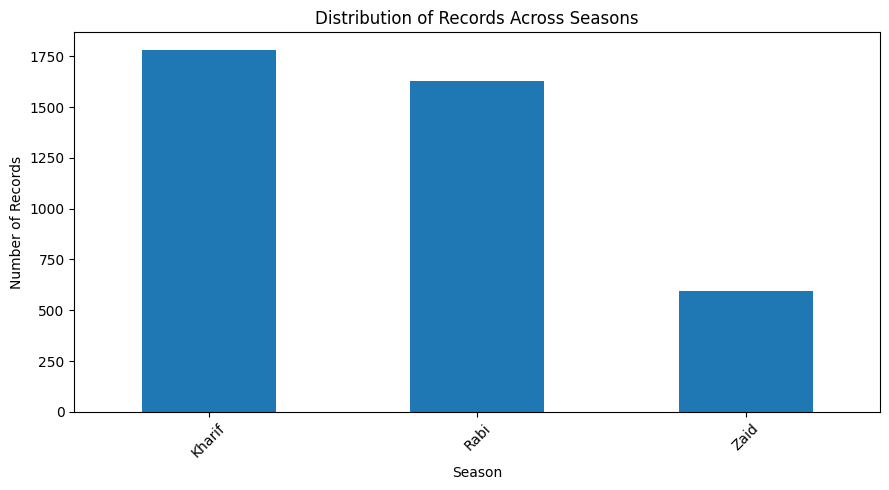

In [14]:
if season_col:
    season_counts = df_clean[season_col].value_counts(dropna=False)

    plt.figure(figsize=(9, 5))
    season_counts.plot(kind="bar")
    plt.title("Distribution of Records Across Seasons")
    plt.xlabel("Season")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Season column not available.")


## 11. Seasonal Comparison of Numerical Variables

For every numerical variable, calculate the mean by season. This provides a broad view of how agricultural conditions, production, resource usage, or economic measures vary across seasons.

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,,
Kharif,7.94,852.08,28.45,71.81,6.79,6.73,31.20,120.02,58.10,105.30,187.08,5.08,0.82,5.64,46.31,44850.91,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,436.00,23.49,57.89,7.59,6.67,24.05,120.40,57.31,103.93,185.41,5.02,0.83,5.08,41.49,44747.97,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,299.42,31.04,52.01,8.18,6.69,19.17,120.53,58.13,105.42,184.64,5.17,0.82,4.67,38.89,44212.03,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


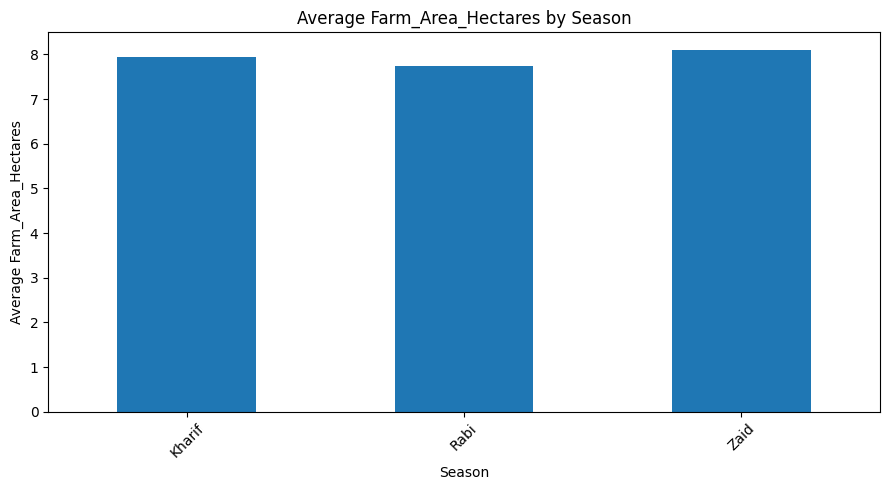

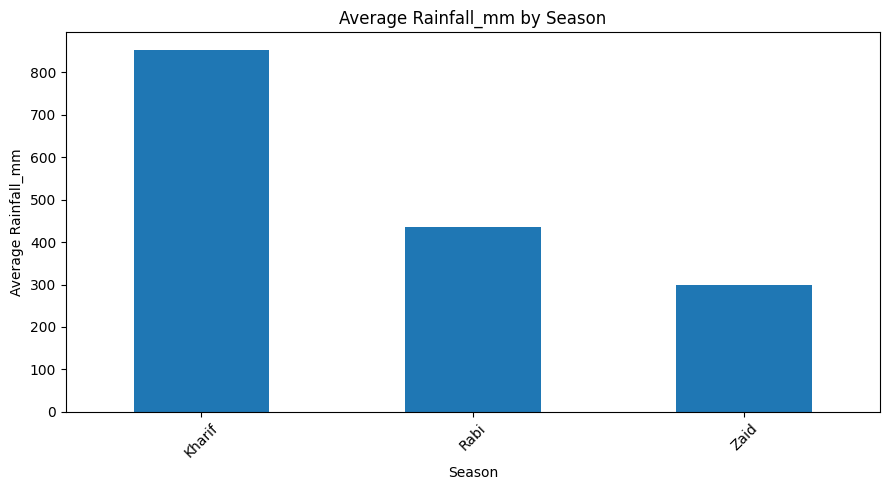

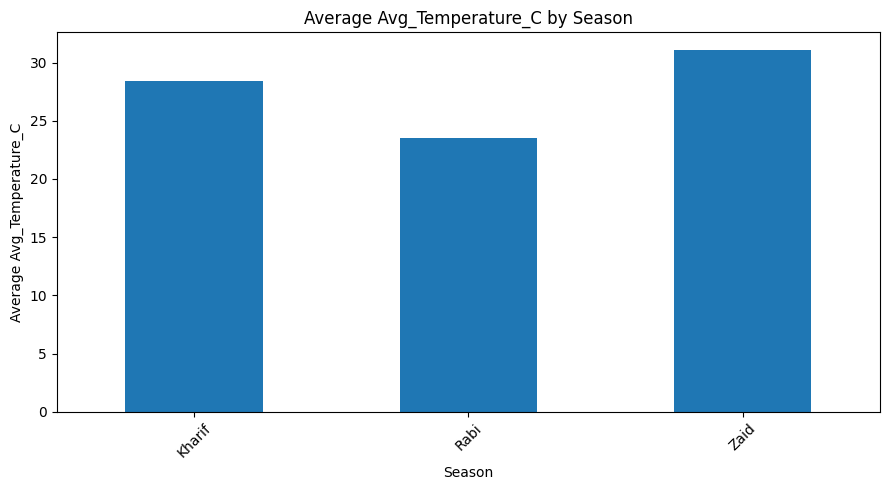

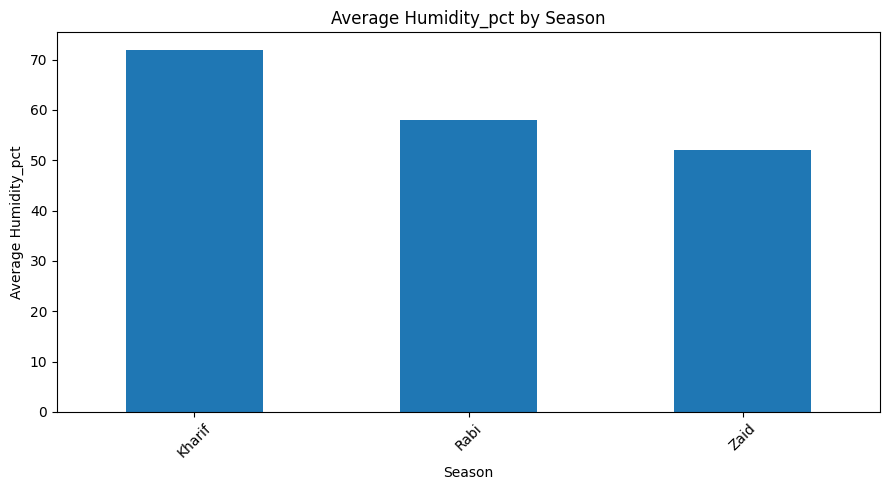

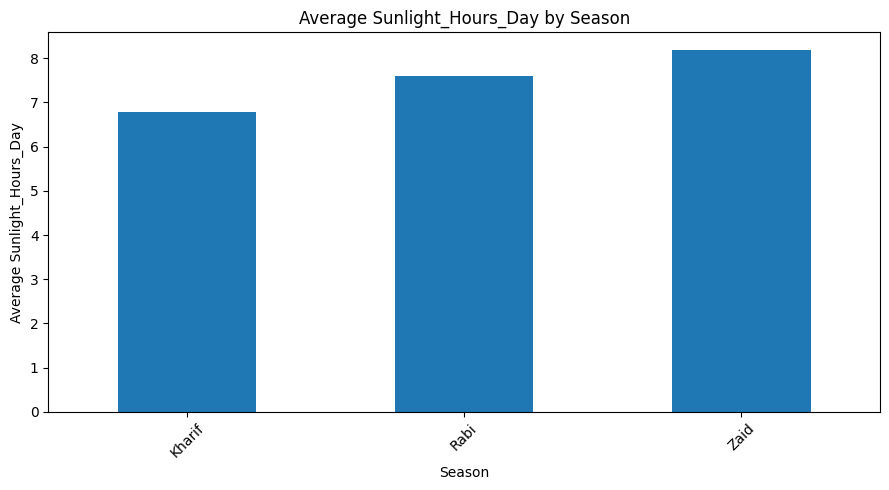

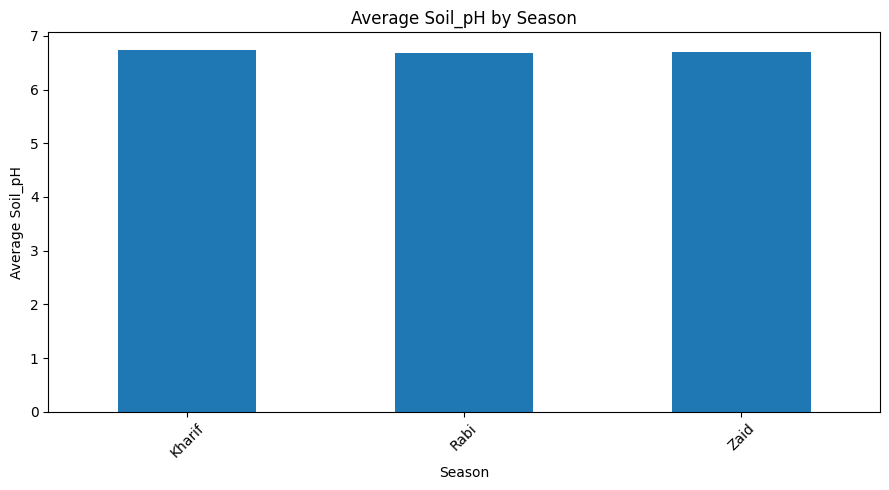

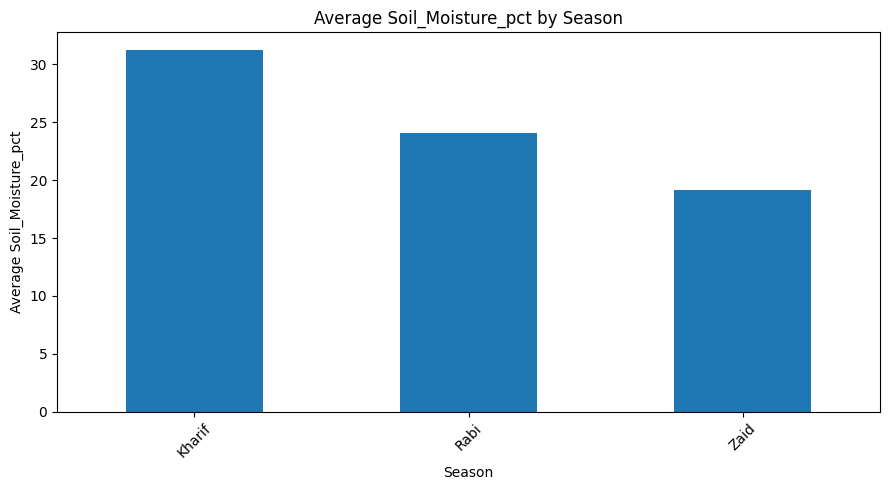

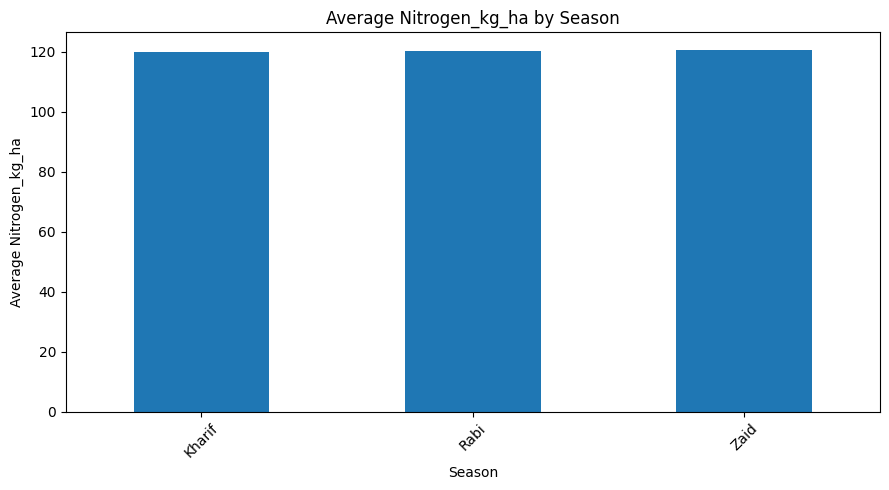

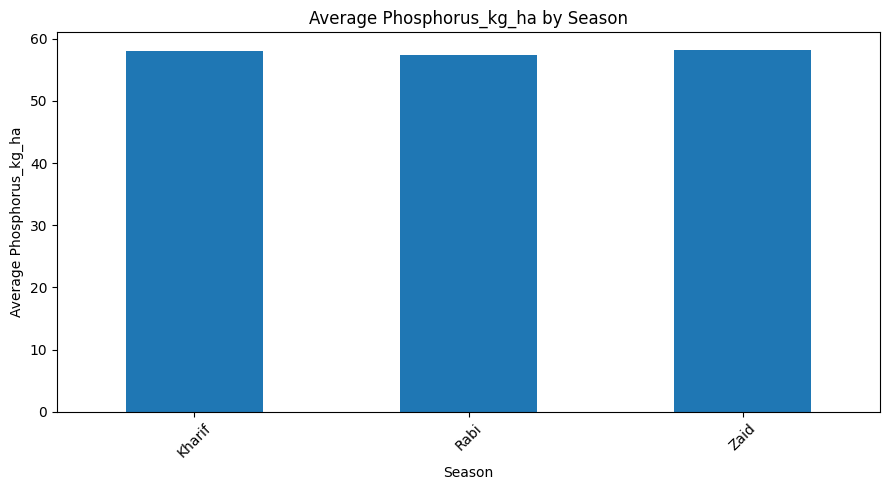

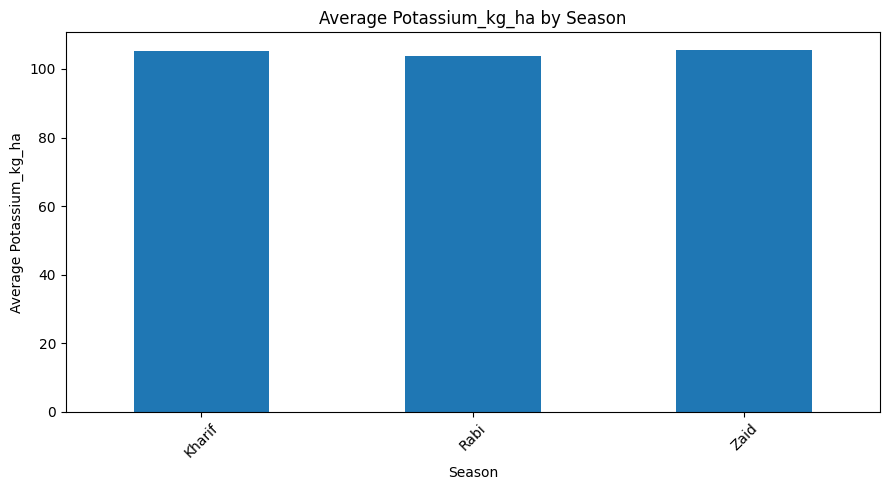

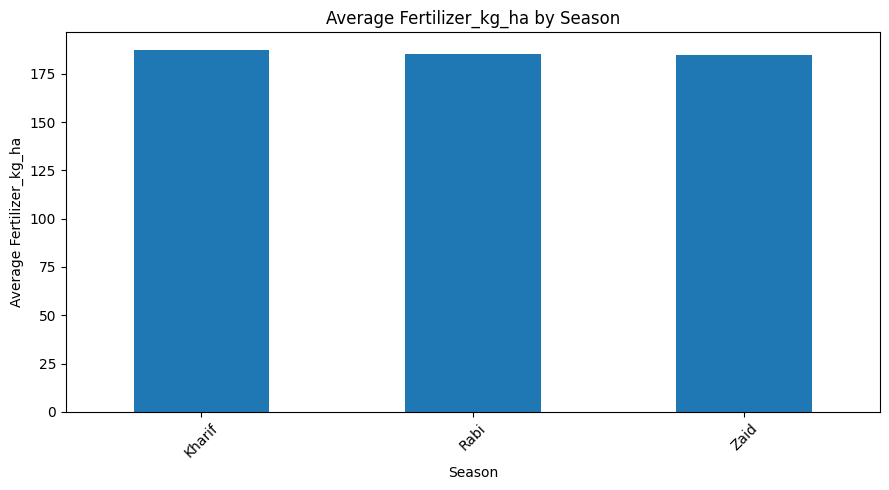

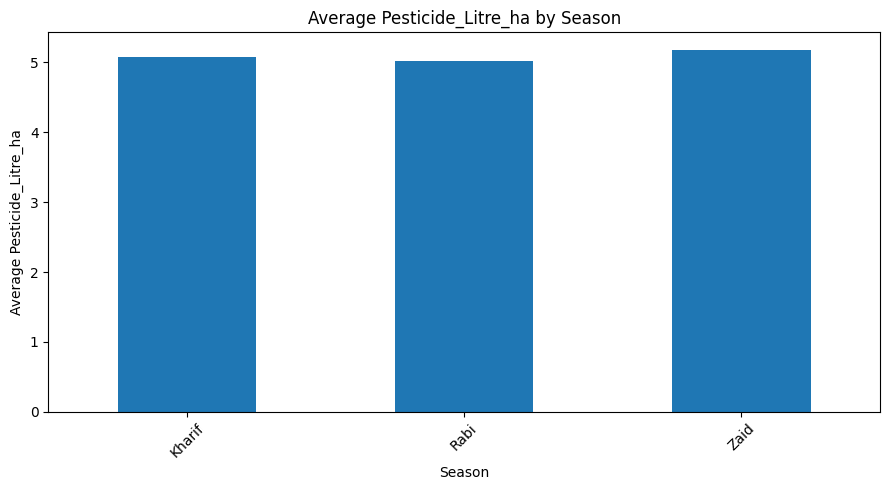

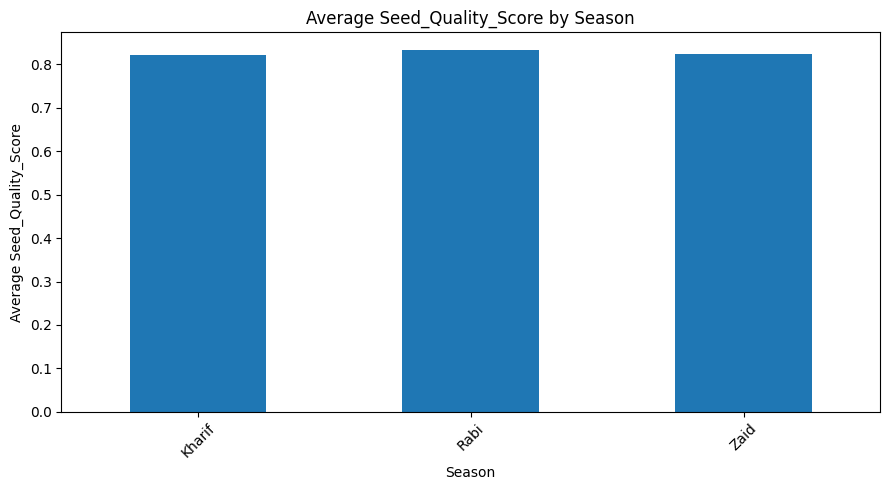

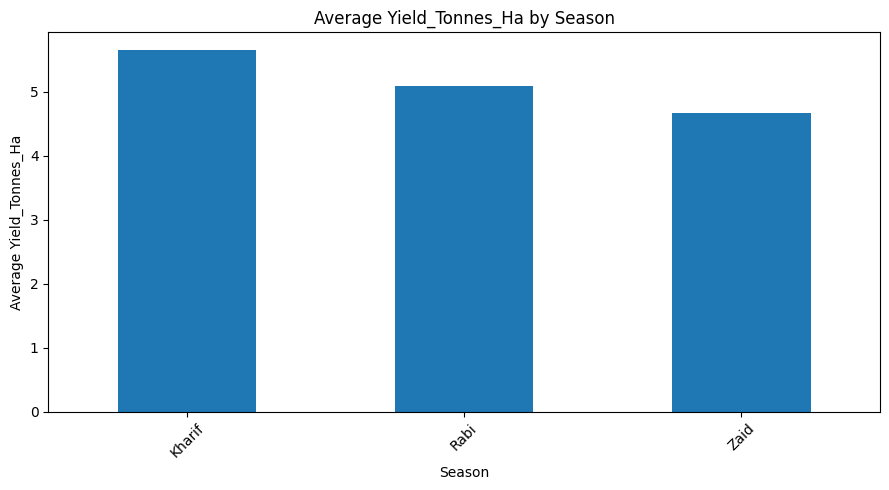

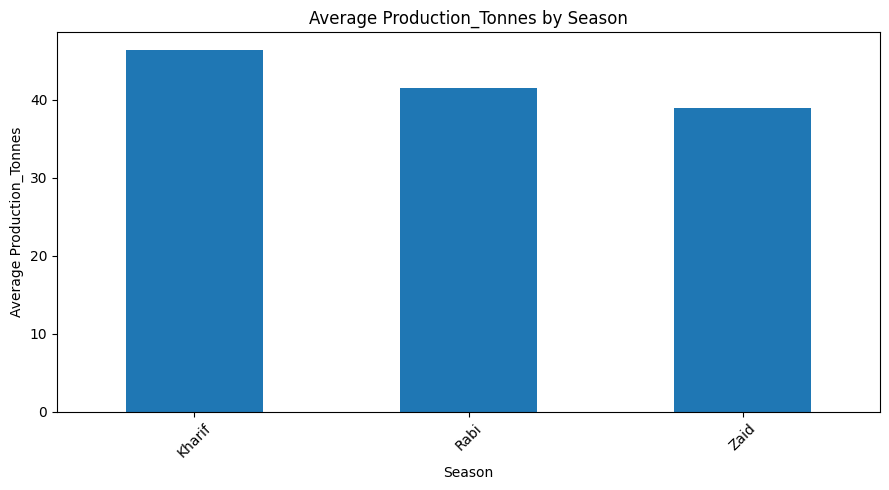

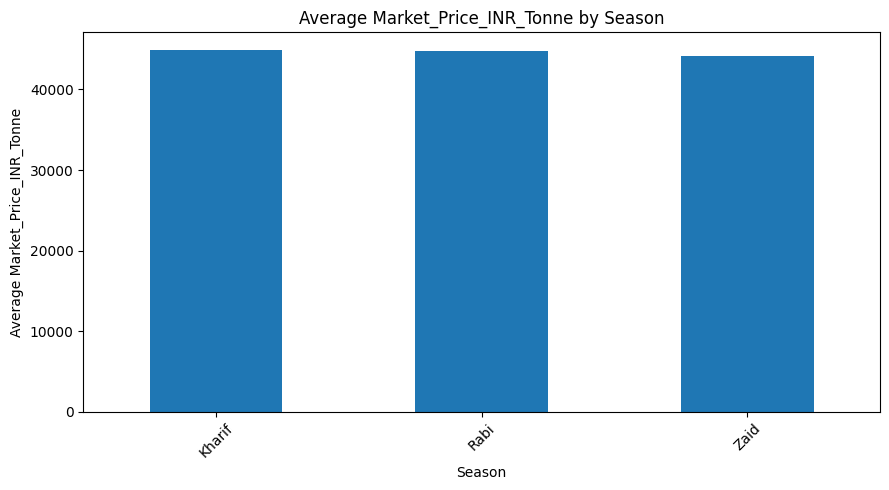

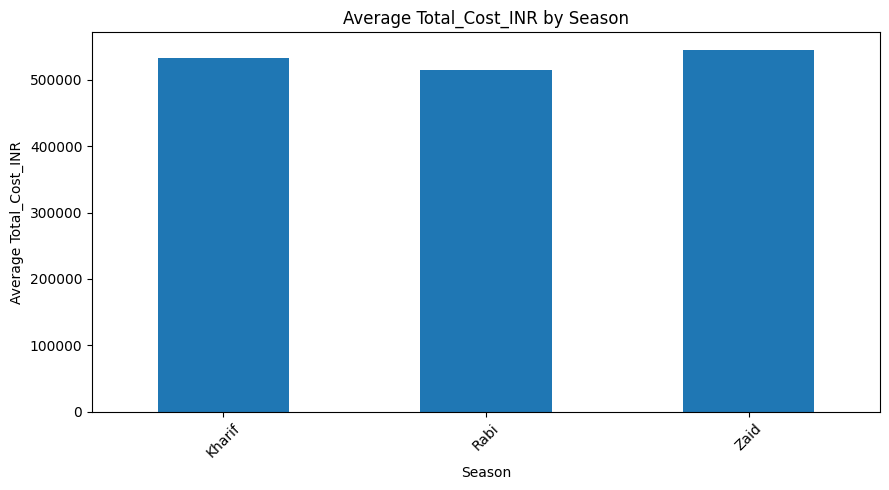

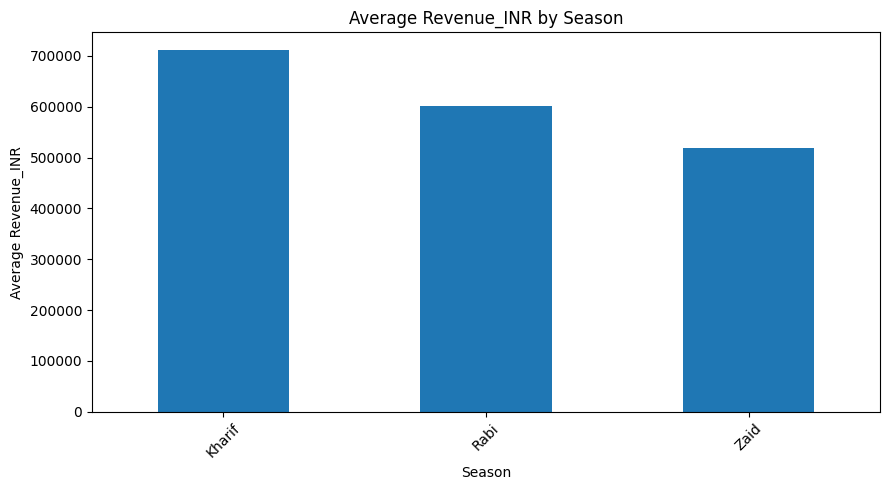

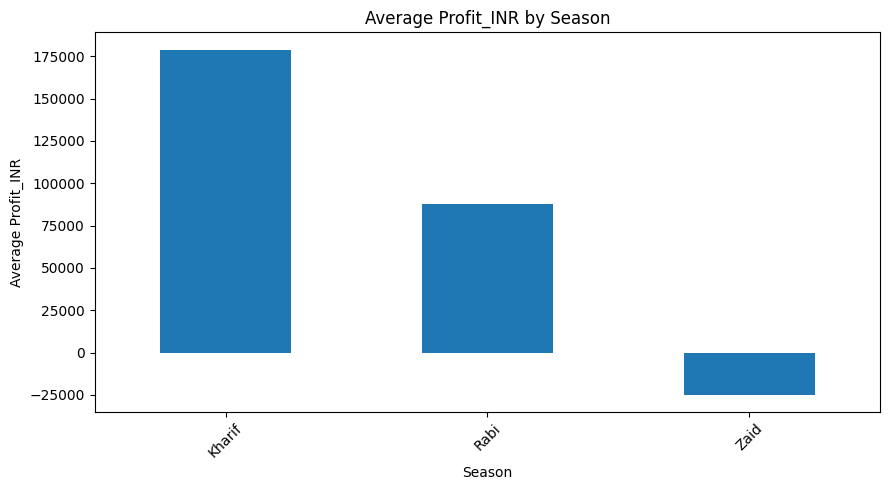

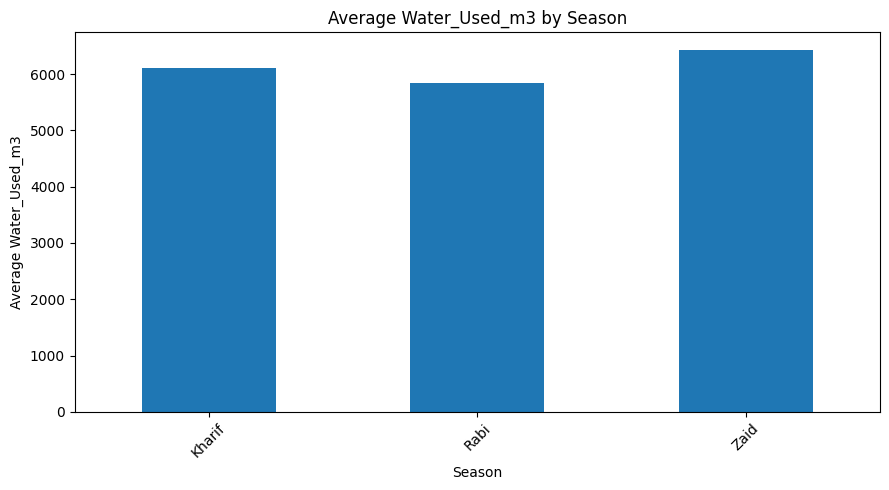

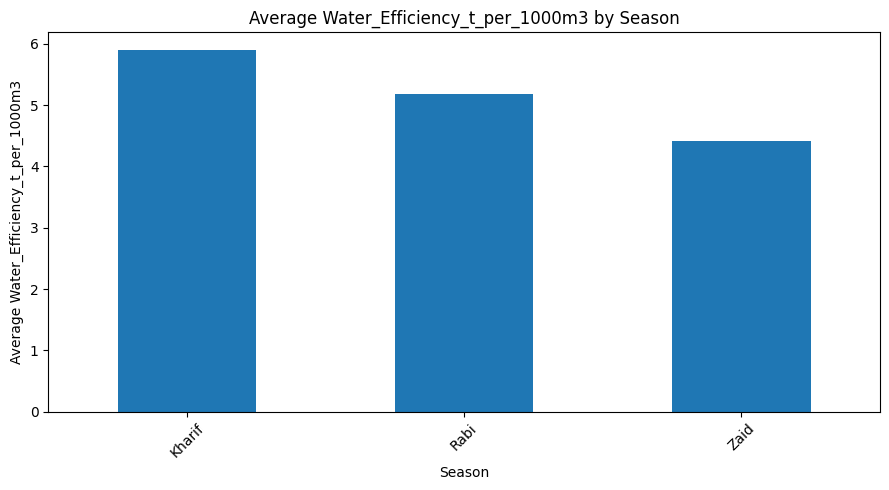

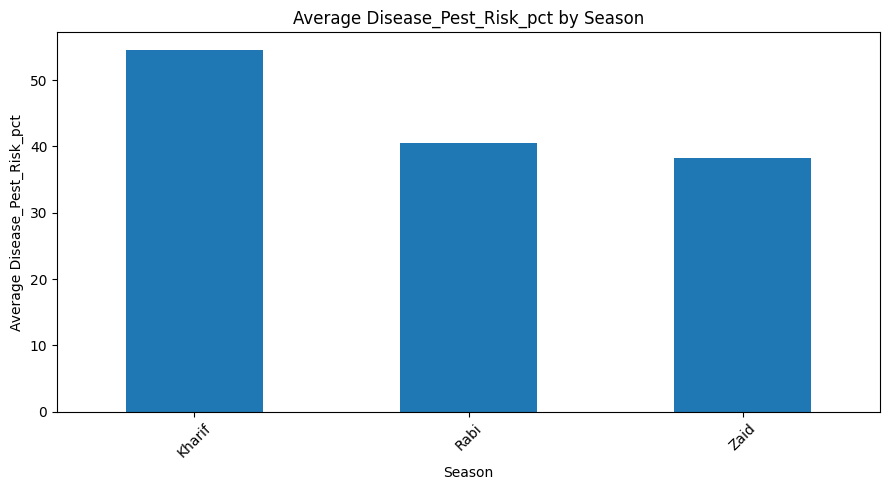

In [15]:
if season_col and numeric_cols:
    seasonal_means = df_clean.groupby(season_col)[numeric_cols].mean(numeric_only=True)
    display(seasonal_means.round(2))

    for col in numeric_cols:
        plt.figure(figsize=(9, 5))
        seasonal_means[col].plot(kind="bar")
        plt.title(f"Average {col} by Season")
        plt.xlabel("Season")
        plt.ylabel(f"Average {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Seasonal numerical analysis requires both a season column and numerical columns.")


## 12. Seasonal Variation

This section measures how much each numerical variable varies across seasons using the difference between its highest and lowest seasonal mean.

In [16]:
if season_col and numeric_cols:
    seasonal_variation = pd.DataFrame({
        "Minimum Seasonal Mean": seasonal_means.min(),
        "Maximum Seasonal Mean": seasonal_means.max(),
        "Range Across Seasons": seasonal_means.max() - seasonal_means.min()
    }).sort_values("Range Across Seasons", ascending=False)

    display(seasonal_variation.round(2))
else:
    print("Seasonal variation analysis requires both a season column and numerical columns.")


,Minimum Seasonal Mean,Maximum Seasonal Mean,Range Across Seasons
Profit_INR,-24804.82,178914.65,203719.47
Revenue_INR,519171.90,710719.06,191547.15
Total_Cost_INR,513836.58,543976.73,30140.15
Market_Price_INR_Tonne,44212.03,44850.91,638.87
Water_Used_m3,5846.99,6419.89,572.91
Rainfall_mm,299.42,852.08,552.66
Humidity_pct,52.01,71.81,19.80
Disease_Pest_Risk_pct,38.22,54.47,16.25
Soil_Moisture_pct,19.17,31.20,12.03
Avg_Temperature_C,23.49,31.04,7.55


## 13. Correlation Analysis

Correlation can help identify relationships among numerical variables. A correlation does **not** by itself prove causation.

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.52,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.63
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


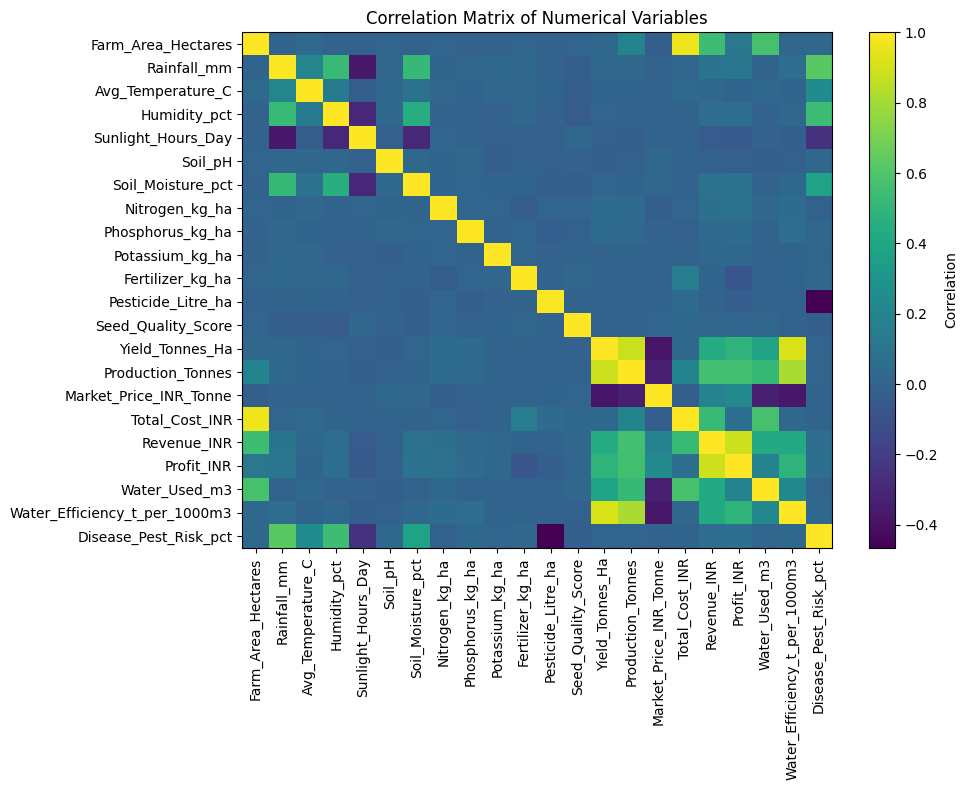

In [17]:
if len(numeric_cols) >= 2:
    corr = df_clean[numeric_cols].corr()

    display(corr.round(2))

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Matrix of Numerical Variables")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numerical columns are required.")


## 14. Strongest Numerical Relationships

In [18]:
if len(numeric_cols) >= 2:
    corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

    print("Top numerical relationships:")
    display(corr_pairs.head(15).to_frame("Correlation"))
else:
    print("Not enough numerical variables.")


Top numerical relationships:


Correlation
Farm_Area_Hectares Total_Cost_INR                    0.962211
Yield_Tonnes_Ha    Water_Efficiency_t_per_1000m3     0.915438
Revenue_INR        Profit_INR                        0.887331
Yield_Tonnes_Ha    Production_Tonnes                 0.885171
Production_Tonnes  Water_Efficiency_t_per_1000m3     0.812143
Rainfall_mm        Disease_Pest_Risk_pct             0.625071
Farm_Area_Hectares Water_Used_m3                     0.576015
Total_Cost_INR     Water_Used_m3                     0.575978
Production_Tonnes  Revenue_INR                       0.563505
                   Profit_INR                        0.554172
Humidity_pct       Disease_Pest_Risk_pct             0.545093
Farm_Area_Hectares Revenue_INR                       0.543364
Rainfall_mm        Humidity_pct                      0.523966
Total_Cost_INR     Revenue_INR                       0.520709
Rainfall_mm        Soil_Moisture_pct                 0.515751

## 15. Relationship with Season

For each categorical variable other than the season field, compare its distribution across seasons when practical.

In [19]:
if season_col:
    other_categorical = [c for c in categorical_cols if c != season_col]

    for col in other_categorical:
        if df_clean[col].nunique(dropna=True) <= 15:
            table = pd.crosstab(df_clean[season_col], df_clean[col])
            print(f"\n### {col} by Season")
            display(table)
else:
    print("Season column not available.")



### State by Season


State,Andhra Pradesh,Gujarat,Karnataka,Madhya Pradesh,Maharashtra,Punjab,Tamil Nadu,Telangana
Season,,,,,,,,
Kharif,240,221,209,226,222,221,206,234
Rabi,204,200,206,208,218,186,208,197
Zaid,85,67,74,63,72,77,71,85



### District by Season


District,Erode,Guntur,Indore,Krishna,Ludhiana,Nalgonda,Nashik,Raichur,Rajkot,Warangal
Season,,,,,,,,,,
Kharif,179,180,183,183,170,172,167,178,165,202
Rabi,154,153,154,159,190,177,145,147,180,168
Zaid,70,57,55,51,67,66,59,61,56,52



### Crop by Season


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85



### Irrigation_Method by Season


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


## 16. Automatic Insight Summary

The following cells generate data-based observations without inventing results.

In [20]:
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total records after cleaning: {len(df_clean)}")
print(f"Total variables: {df_clean.shape[1]}")
print(f"Categorical variables: {len(categorical_cols)}")
print(f"Numerical variables: {len(numeric_cols)}")

if season_col:
    print(f"Season column: {season_col}")
    print(f"Number of seasons/categories: {df_clean[season_col].nunique(dropna=True)}")

if season_col and numeric_cols:
    print("\nNUMERICAL VARIABLES WITH LARGEST SEASONAL MEAN RANGE")
    display(seasonal_variation.head(10).round(2))


DATASET SUMMARY
Total records after cleaning: 4000
Total variables: 28
Categorical variables: 6
Numerical variables: 22
Season column: Season
Number of seasons/categories: 3

NUMERICAL VARIABLES WITH LARGEST SEASONAL MEAN RANGE


,Minimum Seasonal Mean,Maximum Seasonal Mean,Range Across Seasons
Profit_INR,-24804.82,178914.65,203719.47
Revenue_INR,519171.90,710719.06,191547.15
Total_Cost_INR,513836.58,543976.73,30140.15
Market_Price_INR_Tonne,44212.03,44850.91,638.87
Water_Used_m3,5846.99,6419.89,572.91
Rainfall_mm,299.42,852.08,552.66
Humidity_pct,52.01,71.81,19.80
Disease_Pest_Risk_pct,38.22,54.47,16.25
Soil_Moisture_pct,19.17,31.20,12.03
Avg_Temperature_C,23.49,31.04,7.55


## 17. Key Findings — Fill After Reviewing the Charts

Write your final findings here using the actual results from this notebook.

Suggested structure:

1. **Seasonal performance:** Identify which season performs highest/lowest for the most relevant performance metric.
2. **Resource usage:** Explain important seasonal differences in resource-related variables.
3. **Environmental conditions:** Describe major seasonal changes in environmental variables.
4. **Economic outcomes:** Compare revenue, cost, profit, or other economic measures if present.
5. **Relationships:** Mention the strongest meaningful correlations and clarify that correlation does not prove causation.
6. **Unusual patterns:** Note any outliers or unexpected seasonal behavior.


## 18. Recommendations

Recommendations must be based on the findings above.

Possible structure:
- Focus planning on seasons with stronger observed agricultural performance.
- Investigate resource-intensive seasons and evaluate opportunities for efficient resource use.
- Use observed environmental patterns when planning seasonal agricultural activities.
- Investigate unusual or low-performing seasonal results before making operational decisions.
- Use the dataset's economic patterns to support evidence-based seasonal planning.

**Important:** Replace these general statements with recommendations supported by your actual analysis before submission.


## 19. Conclusion

The analysis examines seasonal differences in agricultural performance using data cleaning, descriptive statistics, seasonal comparisons, visualization, and relationship analysis. The final conclusion should summarize the most important evidence found in the dataset and explain how the results can support better seasonal agricultural planning.

## 20. Save Cleaned Dataset

This creates a cleaned CSV that can be retained with the project files.

In [21]:
cleaned_path = Path("/content/seasonal_agriculture_performance_cleaned.csv")
df_clean.to_csv(cleaned_path, index=False)

print(f"Saved: {cleaned_path}")


Saved: /content/seasonal_agriculture_performance_cleaned.csv


## 21. Project Submission Checklist

- [ ] Dataset explored
- [ ] Data cleaned and prepared
- [ ] Missing values reviewed
- [ ] Duplicate records checked
- [ ] Seasonal analysis completed
- [ ] Appropriate visualizations created
- [ ] Relationships investigated
- [ ] Key findings written from actual results
- [ ] Recommendations based on evidence
- [ ] Conclusion completed
- [ ] Notebook saved
- [ ] PPT completed using the instructor-provided template
- [ ] GitHub repository prepared
- [ ] VOIS Data Visualization course completion certificate added to PPT
- [ ] Final submission completed before **10 September 2026**
